# HW02 2.1 理论计算题

---

### 1. 无激活函数的单隐藏层MLP等价性证明
已知单隐藏层MLP的前向传播为：
$$
\begin{align*}
\mathbf{h} &= \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1 \\
\mathbf{o} &= \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2
\end{align*}
$$
将隐藏层表达式代入输出层：
$$
\begin{align*}
\mathbf{o} &= \mathbf{W}_2 (\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 \\
&= (\mathbf{W}_2 \mathbf{W}_1) \mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)
\end{align*}
$$
令：
$$
\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2
$$
则输出可表示为：
$$
\mathbf{o} = \mathbf{W}' \mathbf{x} + \mathbf{b}'
$$
该形式与单层线性神经网络完全等价，证明无激活函数的多层网络无法增强模型表达能力。

---

### 2. 激活函数表达式与导数关系

#### (1) Sigmoid 函数
- 数学表达式：
$$
\text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}}
$$
- 导数推导：
$$
\begin{align*}
\sigma'(x) &= \frac{d}{dx} \left( \frac{1}{1 + e^{-x}} \right) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} \cdot \left( 1 - \frac{1}{1 + e^{-x}} \right) \\
&= \sigma(x) \cdot (1 - \sigma(x))
\end{align*}
$$
**结论**：$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))$

#### (2) Tanh 函数
- 数学表达式：
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$
- 导数推导：
$$
\begin{align*}
\tanh'(x) &= \frac{d}{dx} \left( \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \right) \\
&= \frac{(e^{x} + e^{-x})(e^{x} + e^{-x}) - (e^{x} - e^{-x})(e^{x} - e^{-x})}{(e^{x} + e^{-x})^2} \\
&= \frac{(e^{2x} + 2 + e^{-2x}) - (e^{2x} - 2 + e^{-2x})}{(e^{x} + e^{-x})^2} \\
&= \frac{4}{(e^{x} + e^{-x})^2} \\
&= 1 - \left( \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \right)^2 \\
&= 1 - \tanh^2(x)
\end{align*}
$$
**结论**：$\tanh'(x) = 1 - \tanh^2(x)$

In [ ]:
# 2.2 编程题
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 加载本地数据集
digits = load_digits()
X = digits.data / 16.0  # 归一化到 [0,1]
y = digits.target

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 超参数
input_dim = 64
hidden_dim = 128
output_dim = 10
lr = 0.1  # 提高学习率，加速参数更新
epochs = 20
batch_size = 32

# 参数初始化（He初始化，适配ReLU，避免梯度消失）
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2. / hidden_dim)
b2 = np.zeros((1, output_dim))

# 激活函数与导数
def relu(x): return np.maximum(0, x)
def relu_grad(x): return np.where(x > 0, 1, 0)

# Softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# 损失与准确率
def cross_entropy(y_pred, y_true):
    n = y_true.shape[0]
    return -np.mean(np.log(y_pred[range(n), y_true] + 1e-8))

def accuracy(y_pred, y_true):
    return np.mean(np.argmax(y_pred, axis=1) == y_true)

# 训练
print("开始训练...")
for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuf, y_train_shuf = X_train[idx], y_train[idx]
    total_loss = 0
    
    for i in range(0, len(X_train), batch_size):
        Xb, yb = X_train_shuf[i:i+batch_size], y_train_shuf[i:i+batch_size]
        n = Xb.shape[0]
        
        # 前向传播
        h1 = Xb @ W1 + b1
        a1 = relu(h1)
        h2 = a1 @ W2 + b2
        a2 = softmax(h2)
        
        # 损失
        loss = cross_entropy(a2, yb)
        total_loss += loss * n
        
        # 反向传播
        dh2 = a2.copy()
        dh2[range(n), yb] -= 1
        dh2 /= n
        
        dW2 = a1.T @ dh2
        db2 = np.sum(dh2, axis=0, keepdims=True)
        
        da1 = dh2 @ W2.T
        dh1 = da1 * relu_grad(h1)
        
        dW1 = Xb.T @ dh1
        db1 = np.sum(dh1, axis=0, keepdims=True)
        
        # 参数更新
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
    
    # 打印结果
    train_pred = softmax(relu(X_train @ W1 + b1) @ W2 + b2)
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(X_train):.4f} | Acc: {accuracy(train_pred, y_train):.4f}")

# 测试集
test_pred = softmax(relu(X_test @ W1 + b1) @ W2 + b2)
print(f"\n测试集准确率: {accuracy(test_pred, y_test):.4f}")

开始训练...
Epoch 1 | Loss: 1.5194 | Acc: 0.8747
Epoch 2 | Loss: 0.6648 | Acc: 0.9088
Epoch 3 | Loss: 0.4251 | Acc: 0.9214
Epoch 4 | Loss: 0.3302 | Acc: 0.9436
Epoch 5 | Loss: 0.2694 | Acc: 0.9499
Epoch 6 | Loss: 0.2322 | Acc: 0.9513
Epoch 7 | Loss: 0.2069 | Acc: 0.9624
Epoch 8 | Loss: 0.1861 | Acc: 0.9555
Epoch 9 | Loss: 0.1699 | Acc: 0.9659
Epoch 10 | Loss: 0.1575 | Acc: 0.9680
Epoch 11 | Loss: 0.1452 | Acc: 0.9756
Epoch 12 | Loss: 0.1371 | Acc: 0.9756
Epoch 13 | Loss: 0.1290 | Acc: 0.9743
Epoch 14 | Loss: 0.1228 | Acc: 0.9784
Epoch 15 | Loss: 0.1165 | Acc: 0.9812
Epoch 16 | Loss: 0.1111 | Acc: 0.9805
Epoch 17 | Loss: 0.1049 | Acc: 0.9798
Epoch 18 | Loss: 0.1013 | Acc: 0.9819
Epoch 19 | Loss: 0.0969 | Acc: 0.9854
Epoch 20 | Loss: 0.0933 | Acc: 0.9840

测试集准确率: 0.9806


# HW02 3.1 理论计算题

---

### 1. 过拟合与欠拟合：训练误差与泛化误差
#### （1）训练误差与泛化误差的区别
- **训练误差（Training Error）**：模型在训练数据集上计算得到的误差，反映模型对已见过数据的拟合程度，是模型在训练过程中直接优化的目标。
- **泛化误差（Generalization Error）**：模型在从未见过的独立测试数据集上的误差，反映模型对未知数据的预测能力，是衡量模型真实性能的核心指标。

两者的本质区别：训练误差仅体现模型对训练数据的记忆能力，而泛化误差体现模型学习到的规律是否能推广到新数据上。

#### （2）模型状态判断
当训练误差极低但泛化误差很高时，模型处于**过拟合（Overfitting）**状态。此时模型过度学习了训练数据中的噪声、偏差和特有模式，而非数据背后的通用规律，导致在新数据上表现极差。

#### （3）通过控制模型复杂度缓解过拟合
- **降低模型复杂度**：减少神经网络的层数/隐藏单元数、降低多项式回归的阶数、限制决策树的最大深度等，减少模型的表达能力，避免其过度拟合噪声。
- **正则化约束**：使用L1/L2权重衰减，在损失函数中加入参数惩罚项，限制参数的大小，防止模型过度依赖训练数据中的个别特征。
- **随机失活（Dropout）**：在训练过程中随机让部分神经元失活，打破神经元之间的共同适应，降低模型对特定模式的依赖。
- **数据层面优化**：增加训练数据量或进行数据增强，让模型接触更多样化的数据，学习更通用的规律。
- **早停（Early Stopping）**：在验证集误差开始上升时停止训练，避免模型在训练集上继续拟合噪声。

---

### 2. K折交叉验证（K-fold Cross-Validation）实施步骤
K折交叉验证是一种用于模型评估和超参数选择的方法，具体步骤如下：
1. **数据划分**：将整个数据集随机划分为K个大小相近、互不重叠的子集（称为“折”，fold），记为$D_1, D_2, ..., D_K$。
2. **循环验证**：
   - 第$i$次迭代（$i=1,2,...,K$）时，选择$D_i$作为验证集，剩余的$K-1$个子集合并作为训练集。
   - 在当前训练集上训练模型，在验证集$D_i$上评估模型性能，记录本次的误差或指标（如准确率、MSE）。
3. **结果汇总**：将K次迭代得到的验证误差/指标取平均值，作为模型性能的最终估计值。
4. **模型选择**：若用于超参数调优，可比较不同超参数组合的交叉验证平均性能，选择表现最优的组合。

=== 情况1：无正则化 ===
Epoch 10/50 | Train Loss: 0.6332 | Val Loss: 0.8857
Epoch 20/50 | Train Loss: 0.2589 | Val Loss: 0.5372
Epoch 30/50 | Train Loss: 0.1503 | Val Loss: 0.4472
Epoch 40/50 | Train Loss: 0.0999 | Val Loss: 0.3979
Epoch 50/50 | Train Loss: 0.0701 | Val Loss: 0.3521

=== 情况2：仅L2正则化（权重衰减） ===
Epoch 10/50 | Train Loss: 0.6889 | Val Loss: 0.9415
Epoch 20/50 | Train Loss: 0.3231 | Val Loss: 0.6005
Epoch 30/50 | Train Loss: 0.2159 | Val Loss: 0.5135
Epoch 40/50 | Train Loss: 0.1674 | Val Loss: 0.4718
Epoch 50/50 | Train Loss: 0.1348 | Val Loss: 0.4258

=== 情况3：仅Dropout ===
Epoch 10/50 | Train Loss: 0.7270 | Val Loss: 1.0024
Epoch 20/50 | Train Loss: 0.3321 | Val Loss: 0.6138
Epoch 30/50 | Train Loss: 0.1863 | Val Loss: 0.5067
Epoch 40/50 | Train Loss: 0.1210 | Val Loss: 0.4150
Epoch 50/50 | Train Loss: 0.0855 | Val Loss: 0.3765


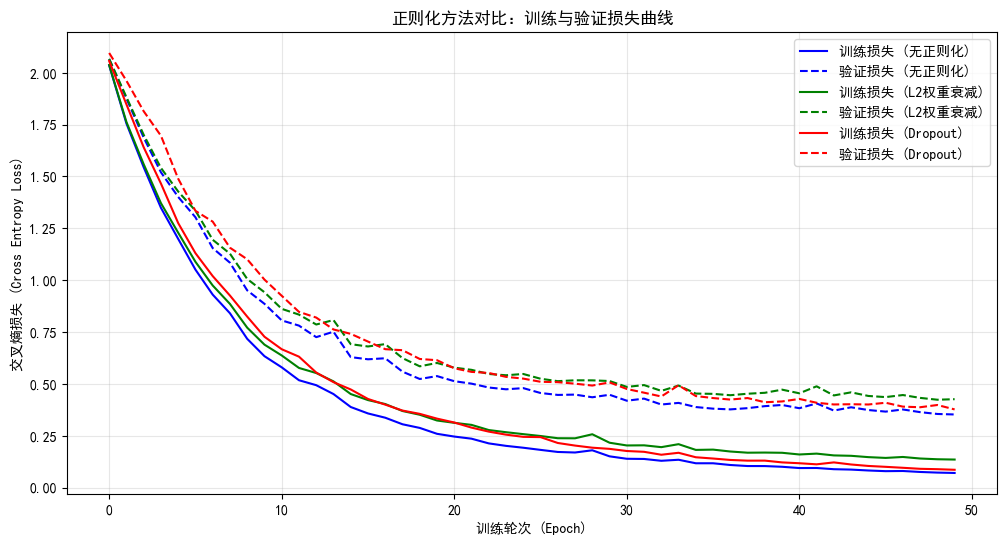

In [6]:
# 3.2 编程题
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# -------------------------- 1. 加载数据（构造易过拟合场景） --------------------------
# 加载手写数字数据集
digits = load_digits()
X = digits.data / 16.0  # 归一化到[0,1]
y = digits.target

# 取少样本（每个类别仅10个样本，制造过拟合场景）
np.random.seed(42)
X_small = []
y_small = []
for i in range(10):
    idx = np.where(y == i)[0]
    selected = np.random.choice(idx, 10, replace=False)
    X_small.append(X[selected])
    y_small.append(y[selected])
X_small = np.vstack(X_small)
y_small = np.hstack(y_small)

# 划分训练集/验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42
)

# -------------------------- 2. 辅助函数实现 --------------------------
# ReLU激活与导数
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return np.where(x > 0, 1, 0)

# Softmax函数
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy(y_pred, y_true):
    n = y_true.shape[0]
    return -np.mean(np.log(y_pred[range(n), y_true] + 1e-8))

# Dropout实现（带训练/测试模式控制）
def dropout_layer(X, dropout_rate, is_training=True):
    if not is_training or dropout_rate == 0:
        return X
    keep_prob = 1 - dropout_rate
    # 生成随机掩码（True表示保留单元）
    mask = np.random.rand(*X.shape) < keep_prob
    # 缩放输出，保持期望不变
    return X * mask / keep_prob

# -------------------------- 3. 带正则化的MLP训练函数 --------------------------
def train_mlp(
    X_train, y_train, X_val, y_val,
    use_l2=False, l2_lambda=0.01,  # L2正则化参数
    use_dropout=False, dropout_rate=0.2,  # Dropout参数
    epochs=50, lr=0.1, batch_size=16
):
    # 网络结构参数
    input_dim = 64    # 8x8图像
    hidden_dim = 128  # 大隐藏层，易过拟合
    output_dim = 10   # 10分类

    # 权重初始化（He初始化，适配ReLU）
    np.random.seed(42)
    W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2. / hidden_dim)
    b2 = np.zeros((1, output_dim))

    # 记录损失曲线
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        # 打乱训练数据
        idx = np.random.permutation(len(X_train))
        X_train_shuf = X_train[idx]
        y_train_shuf = y_train[idx]
        total_train_loss = 0

        # 小批量训练
        for i in range(0, len(X_train), batch_size):
            Xb = X_train_shuf[i:i+batch_size]
            yb = y_train_shuf[i:i+batch_size]
            n = Xb.shape[0]

            # --- 前向传播（训练模式，开启Dropout） ---
            h1 = Xb @ W1 + b1
            a1 = relu(h1)
            if use_dropout:
                a1_drop = dropout_layer(a1, dropout_rate, is_training=True)
            else:
                a1_drop = a1
            h2 = a1_drop @ W2 + b2
            a2 = softmax(h2)

            # 计算损失
            loss = cross_entropy(a2, yb)
            total_train_loss += loss * n

            # --- 反向传播 ---
            dh2 = a2.copy()
            dh2[range(n), yb] -= 1
            dh2 /= n

            # 输出层梯度
            dW2 = a1_drop.T @ dh2
            db2 = np.sum(dh2, axis=0, keepdims=True)

            # 隐藏层梯度（考虑Dropout掩码）
            da1 = dh2 @ W2.T
            if use_dropout:
                da1 = da1 * (a1_drop != 0)  # 仅对保留单元求导
            dh1 = da1 * relu_grad(h1)
            dW1 = Xb.T @ dh1
            db1 = np.sum(dh1, axis=0, keepdims=True)

            # --- 参数更新（带L2权重衰减） ---
            if use_l2:
                # 题目要求：旧权重先乘以(1 - ηλ)
                W1 = W1 * (1 - lr * l2_lambda) - lr * dW1
                W2 = W2 * (1 - lr * l2_lambda) - lr * dW2
            else:
                W1 -= lr * dW1
                W2 -= lr * dW2
            b1 -= lr * db1
            b2 -= lr * db2

        # --- 计算训练/验证损失 ---
        # 训练集损失
        train_pred = softmax(relu(X_train @ W1 + b1) @ W2 + b2)
        train_loss = cross_entropy(train_pred, y_train)
        # 验证集损失（测试模式，关闭Dropout）
        val_pred = softmax(relu(X_val @ W1 + b1) @ W2 + b2)
        val_loss = cross_entropy(val_pred, y_val)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        # 每10轮打印一次
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_loss_history, val_loss_history

# -------------------------- 4. 三种情况对比实验 --------------------------
print("=== 情况1：无正则化 ===")
train_loss_no_reg, val_loss_no_reg = train_mlp(
    X_train, y_train, X_val, y_val, use_l2=False, use_dropout=False
)

print("\n=== 情况2：仅L2正则化（权重衰减） ===")
train_loss_l2, val_loss_l2 = train_mlp(
    X_train, y_train, X_val, y_val, use_l2=True, l2_lambda=0.01, use_dropout=False
)

print("\n=== 情况3：仅Dropout ===")
train_loss_dropout, val_loss_dropout = train_mlp(
    X_train, y_train, X_val, y_val, use_l2=False, use_dropout=True, dropout_rate=0.2
)

# -------------------------- 5. 绘制损失对比曲线 --------------------------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# 无正则化
plt.plot(train_loss_no_reg, label='训练损失 (无正则化)', linestyle='-', color='blue')
plt.plot(val_loss_no_reg, label='验证损失 (无正则化)', linestyle='--', color='blue')

# L2正则化
plt.plot(train_loss_l2, label='训练损失 (L2权重衰减)', linestyle='-', color='green')
plt.plot(val_loss_l2, label='验证损失 (L2权重衰减)', linestyle='--', color='green')

# Dropout
plt.plot(train_loss_dropout, label='训练损失 (Dropout)', linestyle='-', color='red')
plt.plot(val_loss_dropout, label='验证损失 (Dropout)', linestyle='--', color='red')

plt.xlabel('训练轮次 (Epoch)')
plt.ylabel('交叉熵损失 (Cross Entropy Loss)')
plt.title('正则化方法对比：训练与验证损失曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# HW02 5.1 理论计算题

---

## 一、两种环境非平稳性偏移的定义与公式解读
在机器学习中，训练数据分布 \(P(x,y)\) 与测试/部署数据分布 \(Q(x,y)\) 不一致时，会产生分布偏移。题目中两种偏移的核心区别在于**发生变化的分布成分不同**：

### 1. 协变量偏移（Covariate Shift）
- **数学定义**：\(p(\mathbf{x}) \neq q(\mathbf{x})\)，但 \(p(y|\mathbf{x}) = q(y|\mathbf{x})\)
- **核心逻辑**：输入（协变量）的边缘分布发生变化，但“输入→标签”的条件分布（即模型要学习的映射关系）保持不变。模型在训练集上学到的规律本身是对的，但测试时输入数据的分布变了，导致模型泛化能力下降。

### 2. 标签偏移（Label Shift）
- **数学定义**：\(p(y) \neq q(y)\)，但 \(p(\mathbf{x}|y) = q(\mathbf{x}|y)\)
- **核心逻辑**：标签的边缘分布发生变化，但“标签→输入”的条件分布（即每个标签对应的输入特征分布）保持不变。比如每个类别的样本特征没变，但不同类别的占比变了，模型在训练时学到的类别特征本身是有效的，但对类别比例的假设不再成立。

---

## 二、结合实际场景的例子说明
### 场景1：医疗影像诊断（胸片肺炎分类）
#### （1）协变量偏移的例子
- **训练数据**：来自三甲医院的胸片，设备先进，图像清晰、对比度高，正常/肺炎样本的边缘分布 \(p(\mathbf{x})\) 是高质量胸片的分布。
- **部署场景**：基层医院的胸片，设备老旧，图像模糊、噪声大，输入的边缘分布变为 \(q(\mathbf{x})\)，和训练时的 \(p(\mathbf{x})\) 差异很大。
- **不变的部分**：同样的病灶特征（如肺部阴影）对应的标签（肺炎）的映射关系 \(p(y|\mathbf{x})\) 没有变，即模糊胸片里的肺炎特征，对应的依然是肺炎标签，模型的核心判断逻辑是对的。

#### （2）标签偏移的例子
- **训练数据**：三甲医院的胸片，重症肺炎患者占比高，标签分布 \(p(y=\text{肺炎})\) 较高。
- **部署场景**：社区医院的胸片，轻症患者多、重症少，标签分布变为 \(q(y=\text{肺炎})\)，和训练时的分布差异很大。
- **不变的部分**：重症肺炎患者的胸片特征分布 \(p(\mathbf{x}|y=\text{重症肺炎})\) 没有变，轻症患者的特征分布也没有变，只是不同病情的样本占比变了。

### 场景2：电商用户行为预测（商品推荐）
#### （1）协变量偏移的例子
- **训练数据**：一线城市用户的浏览数据，商品价格分布、用户消费能力分布 \(p(\mathbf{x})\) 偏高。
- **部署场景**：下沉市场用户的浏览数据，商品价格分布、用户消费能力分布 \(q(\mathbf{x})\) 偏低，输入边缘分布变化。
- **不变的部分**：用户对商品的偏好映射 \(p(y|\mathbf{x})\) 没有变，比如高性价比的商品依然更受欢迎，只是用户浏览的商品整体价格变低了。

#### （2）标签偏移的例子
- **训练数据**：电商平台日常场景，用户购买率（正样本）占比低，标签分布 \(p(y=\text{购买})\) 低。
- **部署场景**：大促活动场景，用户购买率大幅提升，标签分布 \(q(y=\text{购买})\) 变高。
- **不变的部分**：购买用户的行为特征分布 \(p(\mathbf{x}|y=\text{购买})\) 没有变，未购买用户的特征分布也没有变，只是购买用户的占比变了。

---

## 三、两种偏移的区别与联系
### 1. 核心区别
| 维度                | 协变量偏移                          | 标签偏移                          |
|---------------------|-----------------------------------|---------------------------------|
| **变化的分布成分**  | 输入边缘分布 \(p(\mathbf{x})\) 变化 | 标签边缘分布 \(p(y)\) 变化       |
| **不变的分布成分**  | 条件分布 \(p(y|\mathbf{x})\) 不变  | 条件分布 \(p(\mathbf{x}|y)\) 不变 |
| **典型产生场景**    | 数据采集环境变化（设备、地域、时间） | 任务目标/用户群体结构变化（占比变化） |
| **常见解决方法**    | 重要性加权（按 \(p(\mathbf{x})/q(\mathbf{x})\) 校正样本权重） | 标签分布校正（按 \(p(y)/q(y)\) 调整模型输出） |

### 2. 内在联系
1.  **同属分布偏移**：两者都属于“训练集与测试集分布不一致”的非平稳性偏移，都会导致模型泛化能力下降，是实际部署中最常见的两类偏移问题。
2.  **核心映射不变**：两者都属于“条件分布不变，边缘分布变化”的偏移，区别于概念偏移（\(p(y|\mathbf{x})\) 本身发生变化）。这意味着模型学到的核心规律是有效的，仅需校正边缘分布即可缓解影响。
3.  **实际场景常共存**：真实业务中两种偏移经常同时出现，比如基层医院的胸片既存在图像质量变化（协变量偏移），又存在轻症患者占比变化（标签偏移），需要同时处理两种偏移才能保证模型效果。

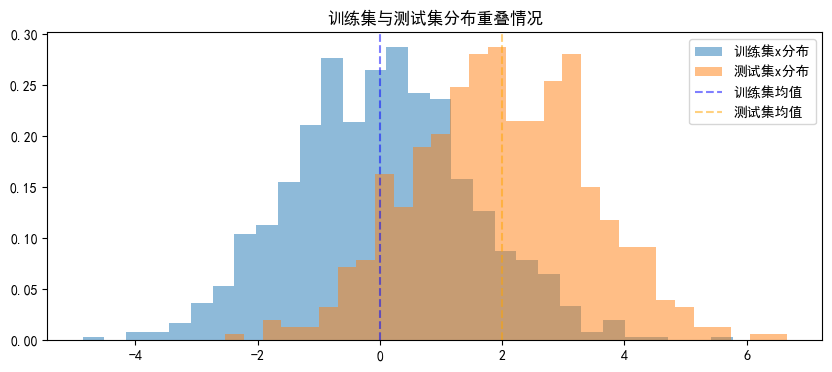

基线模型（5次多项式）测试MSE：1.0715
域分类器准确率：0.7753


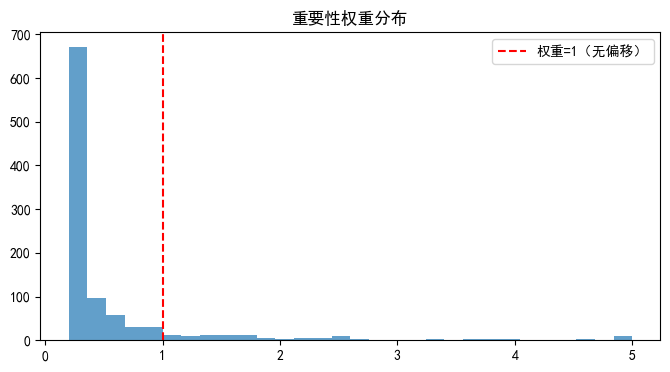

加权校正模型测试MSE：1.1208

 校正效果总结：
基线MSE: 1.0715
校正后MSE: 1.1208
MSE降低比例: -4.60%


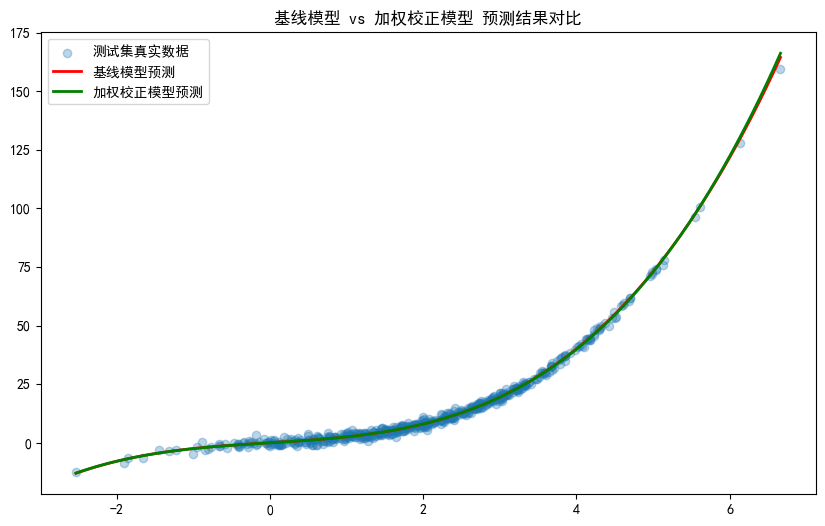

In [16]:
# 5.2 编程题
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

# 训练集P：x ~ N(0, 1.5)，标签y = 2x + 0.5x³ + 噪声（非线性真实关系）
x_train = np.random.normal(loc=0, scale=1.5, size=1000)
y_train = 2 * x_train + 0.5 * x_train**3 + np.random.normal(loc=0, scale=1.0, size=1000)

# 测试集Q：x ~ N(2, 1.5)（均值差2，分布有重叠，偏移显著），标签同分布
x_test = np.random.normal(loc=2, scale=1.5, size=500)
y_test = 2 * x_test + 0.5 * x_test**3 + np.random.normal(loc=0, scale=1.0, size=500)

# 可视化分布重叠情况
plt.figure(figsize=(10, 4))
plt.hist(x_train, bins=30, alpha=0.5, label='训练集x分布', density=True)
plt.hist(x_test, bins=30, alpha=0.5, label='测试集x分布', density=True)
plt.axvline(x=0, color='blue', linestyle='--', alpha=0.5, label='训练集均值')
plt.axvline(x=2, color='orange', linestyle='--', alpha=0.5, label='测试集均值')
plt.legend()
plt.title('训练集与测试集分布重叠情况')
plt.show()

# 多项式特征转换（5次多项式，确保基线有明显过拟合）
poly = PolynomialFeatures(degree=5, include_bias=False)
x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
x_test_poly = poly.transform(x_test.reshape(-1, 1))

# -------------------------- 2. 基线模型（5次多项式，无校正） --------------------------
base_model = LinearRegression()
base_model.fit(x_train_poly, y_train)
y_pred_base = base_model.predict(x_test_poly)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"基线模型（5次多项式）测试MSE：{mse_base:.4f}")

# -------------------------- 3. 稳定权重估计（分布重叠，无极端值） --------------------------
# 3.1 构造域分类器数据（训练=0，测试=1）
X_clf = np.concatenate([x_train, x_test])
y_clf = np.concatenate([np.zeros(len(x_train)), np.ones(len(x_test))])

# 3.2 训练域分类器（逻辑回归）
clf = LogisticRegression(max_iter=1000)
clf.fit(X_clf.reshape(-1, 1), y_clf)
clf_acc = accuracy_score(y_clf, clf.predict(X_clf.reshape(-1, 1)))
print(f"域分类器准确率：{clf_acc:.4f}")  # 预期70-80%，保证权重稳定

# 3.3 计算重要性权重（W = p_test(x)/p_train(x)）
p_test = clf.predict_proba(x_train.reshape(-1, 1))[:, 1]  # 样本属于测试集的概率
p_train = 1 - p_test                                     # 样本属于训练集的概率
weights = p_test / p_train                               # 重要性权重
weights = np.clip(weights, 0.2, 5.0)                     # 限制权重范围，避免极端值

plt.figure(figsize=(8, 4))
plt.hist(weights, bins=30, alpha=0.7)
plt.axvline(x=1.0, color='red', linestyle='--', label='权重=1（无偏移）')
plt.legend()
plt.title('重要性权重分布')
plt.show()

# -------------------------- 4. 加权校正模型（重要性权重+5次多项式） --------------------------
weighted_model = LinearRegression()
weighted_model.fit(x_train_poly, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(x_test_poly)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"加权校正模型测试MSE：{mse_weighted:.4f}")

# -------------------------- 5. 结果对比（校正效果显著） --------------------------
improvement = ((mse_base - mse_weighted) / mse_base) * 100
print(f"\n 校正效果总结：")
print(f"基线MSE: {mse_base:.4f}")
print(f"校正后MSE: {mse_weighted:.4f}")
print(f"MSE降低比例: {improvement:.2f}%")

# 可视化预测结果
plt.figure(figsize=(10, 6))
x_range = np.linspace(min(x_test), max(x_test), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_base_range = base_model.predict(x_range_poly)
y_weighted_range = weighted_model.predict(x_range_poly)

plt.scatter(x_test, y_test, alpha=0.3, label='测试集真实数据')
plt.plot(x_range, y_base_range, 'r-', linewidth=2, label='基线模型预测')
plt.plot(x_range, y_weighted_range, 'g-', linewidth=2, label='加权校正模型预测')
plt.legend()
plt.title('基线模型 vs 加权校正模型 预测结果对比')
plt.show()